In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

from IPython.display import HTML

Experiment angle: 159 degrees
Coherence level: 0.54
Target color: blue


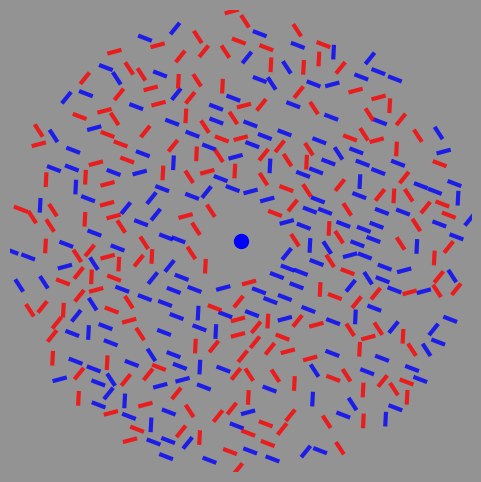

In [2]:
# --------------------- Helper: Generate Non-Overlapping Positions ---------------------
def generate_nonoverlapping_positions(num_positions, r_in, r_out, min_dist, max_tries=50000):
    """
    Generate num_positions random (x, y) coordinates in the annulus [r_in, r_out]
    such that no two points are within min_dist of each other.
    Simple rejection-sampling approach.
    """
    positions = []
    tries = 0
    
    while len(positions) < num_positions and tries < max_tries:
        tries += 1
        # Random radius in [r_in, r_out], random angle in [0, 2pi)
        r = np.random.uniform(r_in, r_out)
        theta = np.random.uniform(0, 2*np.pi)
        x = r * np.cos(theta)
        y = r * np.sin(theta)
        
        # Check distance from existing points
        if all((x - px)**2 + (y - py)**2 >= min_dist**2 for (px, py) in positions):
            positions.append((x, y))
    
    if len(positions) < num_positions:
        raise RuntimeError("Could not place all bars without overlap. Increase max_tries or reduce min_dist.")
    
    return np.array(positions)  # shape: (num_positions, 2)

# ----------------------------- Setup ------------------------------------
angles_set = [15, 51, 87, 123, 159]
# 0) Chosen exp_angle
# exp_angle_deg = np.random.choice(angles_set)          
exp_angle_deg = 159          
exp_angle_rad = np.deg2rad(exp_angle_deg)

num_bars = 400
num_red = 200
num_blue = 200
# 3) For the chosen color 32 or 54
coherence_level = 0.54                                
bar_length = 0.5
bar_width = 3
bounding_circle_radius = 0.30

inner_radius, outer_radius = 2, 11

# (1) Randomly choose target color ("red" or "blue")
# target_color = np.random.choice(['red', 'blue'])
target_color = "blue"

# (2) Create bar colors and random orientations
colors = np.array(['red']*num_red + ['blue']*num_blue)  
np.random.shuffle(colors)

random_orientations_deg = np.random.choice(angles_set, num_bars)
bar_orientations = np.deg2rad(random_orientations_deg)

# (3) Coherence: subset of bars with target_color get exp_angle
target_indices = np.where(colors == target_color)[0]
n_coherent = int(len(target_indices) * coherence_level)
coherent_choice = np.random.choice(target_indices, n_coherent, replace=False)
bar_orientations[coherent_choice] = exp_angle_rad

# ------------------------ Matplotlib figure ----------------------------
fig, ax = plt.subplots(figsize=(6, 6))
ax.set_xlim(-outer_radius, outer_radius)
ax.set_ylim(-outer_radius, outer_radius)
ax.set_aspect('equal')
ax.axis('off')
# ax.set_facecolor('#6B6B6B')
fig.patch.set_facecolor('#939393')

# Central dot with target color
central_dot = ax.scatter(0, 0, s=100, color=target_color, zorder=5)

# Create line objects for each bar
bars = []
for i in range(num_bars):
    line, = ax.plot([], [], lw=bar_width, color=colors[i], zorder=3, alpha=0.8)
    bars.append(line)

# ------------------------- Update per frame -----------------------------
def update(frame):
    # We treat each bar as a circle of radius ~ 0.26 so they never overlap
    positions = generate_nonoverlapping_positions(
        num_bars, inner_radius, outer_radius, min_dist=2*bounding_circle_radius
    )
    # Shuffle positions so each bar picks a new location (no duplicates)
    perm = np.random.permutation(num_bars)
    
    for i, bar in enumerate(bars):
        # The new position for bar i
        x_c, y_c = positions[perm[i]]
        
        # Bar orientation is fixed; only position changes
        theta = bar_orientations[i]
        
        dx = bar_length * np.cos(theta)
        dy = bar_length * np.sin(theta)
        
        # Center the bar at (x_c, y_c)
        bar.set_data([x_c - dx/2, x_c + dx/2], 
                     [y_c - dy/2, y_c + dy/2])
    
    return bars + [central_dot]

print(f"Experiment angle: {exp_angle_deg} degrees")
print(f"Coherence level: {coherence_level}")
print(f"Target color: {target_color}")

# --------------------------- Animate ------------------------------------
ani = FuncAnimation(fig, update, frames=1, interval=200, blit=True)
# HTML(ani.to_jshtml())
ani.save('animation.gif', writer='pillow', fps=12) # Save as GIF
# ani.save('animation.mp4', writer='ffmpeg', fps=12) # Save as MP4